# Classificação de dígitos manuscritos

Mini-projeto avaliativo — Módulo 02.

**Estado:** análise exploratória, divisão estratificada e normalização concluídas. KNN ajustado e selecionado na validação; os demais modelos serão implementados nas próximas etapas.

## 1. Configuração do ambiente

In [1]:
import sys
from importlib.metadata import version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from time import perf_counter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

In [2]:
RANDOM_STATE = 42
CACHE_DIR = Path("data/cache")
FIGURES_DIR = Path("reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

### Verificação

A execução deve utilizar Python 3.12 no ambiente virtual do projeto.

In [3]:
print(f"Python: {sys.version.split()[0]}")
print(f"Ambiente virtual ativo: {sys.prefix != sys.base_prefix}")

bibliotecas = ["numpy", "pandas", "matplotlib", "scikit-learn", "ipykernel"]
pd.DataFrame({
    "Biblioteca": bibliotecas,
    "Versão": [version(nome) for nome in bibliotecas],
})

Python: 3.12.13
Ambiente virtual ativo: True


,Biblioteca,Versão
0,numpy,2.5.3
1,pandas,3.0.5
2,matplotlib,3.11.1
3,scikit-learn,1.9.0
4,ipykernel,7.3.0


## 2. Carregamento e análise exploratória — Fase 1

Fonte: [MNIST no OpenML, conjunto 554](https://www.openml.org/d/554), `mnist_784`, versão 1. As verificações desta etapa descrevem a base integral; não são medidas de desempenho de um modelo.

In [4]:
mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False,
    parser="auto",
    data_home=str(CACHE_DIR),
)

X = mnist.data
y = mnist.target.astype(np.uint8)

print("Dimensões de X:", X.shape)
print("Dimensões de y:", y.shape)

Dimensões de X: (70000, 784)
Dimensões de y: (70000,)


### Estrutura e integridade

In [5]:
assert X.shape == (70_000, 784)
assert y.shape == (70_000,)
assert np.array_equal(np.unique(y), np.arange(10))
assert np.isfinite(X).all()
assert X.min() >= 0 and X.max() <= 255

pd.Series({
    "Imagens": X.shape[0],
    "Pixels por imagem": X.shape[1],
    "Tipo dos pixels": str(X.dtype),
    "Tipo dos rótulos": str(y.dtype),
    "Menor intensidade": X.min(),
    "Maior intensidade": X.max(),
    "Valores ausentes em X": int(np.isnan(X).sum()),
}, name="Diagnóstico").to_frame()

,Diagnóstico
Imagens,70000
Pixels por imagem,784
Tipo dos pixels,int64
Tipo dos rótulos,uint8
Menor intensidade,0
Maior intensidade,255
Valores ausentes em X,0


### Distribuição dos dígitos

In [6]:
contagens = pd.Series(y).value_counts().sort_index()
distribuicao = pd.DataFrame({
    "Quantidade": contagens,
    "Percentual (%)": contagens / len(y) * 100,
})
distribuicao.index.name = "Dígito"

assert distribuicao["Quantidade"].sum() == len(y)
assert np.isclose(distribuicao["Percentual (%)"].sum(), 100)
distribuicao.round(2)

,Quantidade,Percentual (%)
Dígito,,
0,6903,9.86
1,7877,11.25
2,6990,9.99
3,7141,10.20
4,6824,9.75
5,6313,9.02
6,6876,9.82
7,7293,10.42
8,6825,9.75


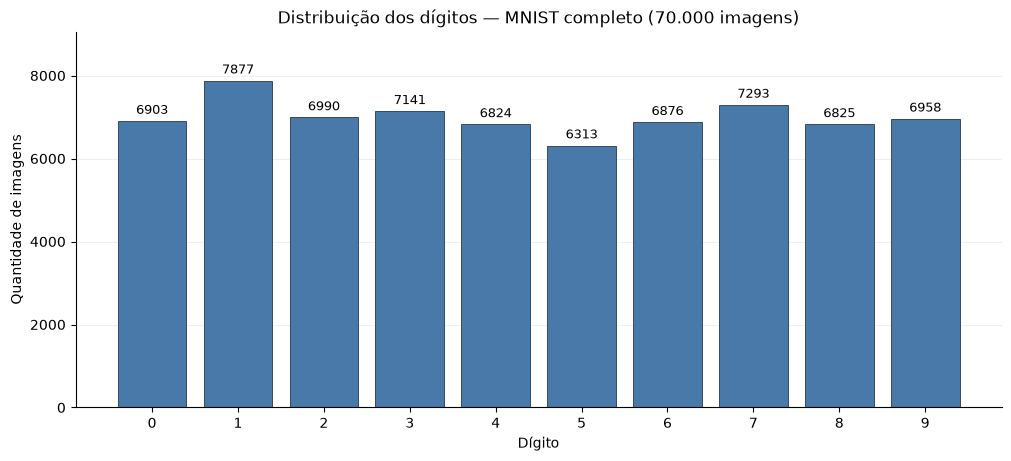

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.5), layout="constrained")
barras = ax.bar(contagens.index, contagens.values, color="#4879A8", edgecolor="#26384A", linewidth=0.6)
ax.bar_label(barras, padding=3, fontsize=9)
ax.set(title="Distribuição dos dígitos — MNIST completo (70.000 imagens)",
       xlabel="Dígito", ylabel="Quantidade de imagens",
       xticks=np.arange(10), ylim=(0, contagens.max() * 1.15))
ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)
ax.grid(axis="y", alpha=0.2)
fig.savefig(FIGURES_DIR / "distribuicao_classes.png", dpi=150)
plt.show()

### Exemplos de cada classe

A grade mostra a primeira ocorrência de cada dígito na base, com escala de intensidade idêntica em todos os painéis.

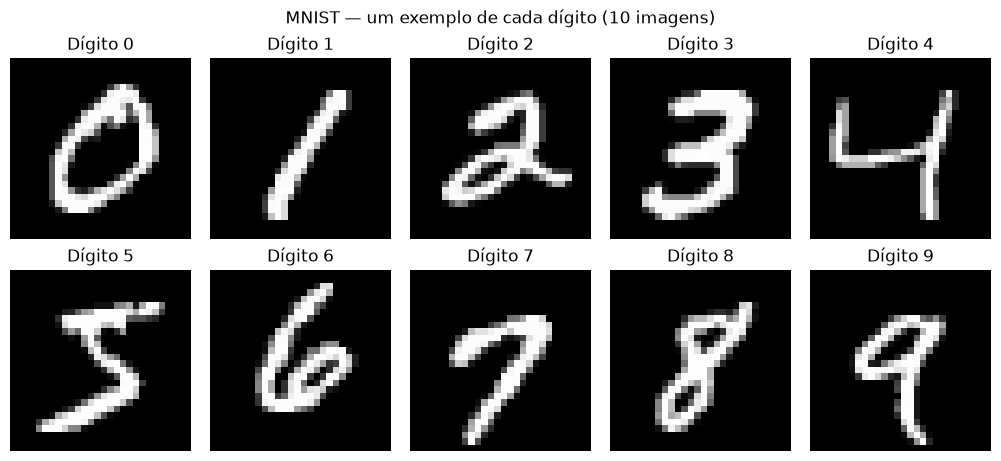

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5), layout="constrained")

for digito, ax in zip(range(10), axes.flat):
    indice = np.flatnonzero(y == digito)[0]
    ax.imshow(X[indice].reshape(28, 28), cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    ax.set_title(f"Dígito {y[indice]}")
    ax.axis("off")

fig.suptitle("MNIST — um exemplo de cada dígito (10 imagens)")
fig.savefig(FIGURES_DIR / "exemplos_digitos.png", dpi=150)
plt.show()

### Imagem e representação vetorial

Cada imagem contém 28 × 28 = 784 intensidades: 0 indica preto, 255 indica branco e os valores intermediários representam tons de cinza. O OpenML já fornece cada imagem achatada em uma linha de `X`. A operação `reshape(28, 28)` recupera a disposição bidimensional preservando a ordem dos pixels.

Forma do vetor: (784,)
Forma da imagem: (28, 28)
A transformação preservou todos os pixels: True


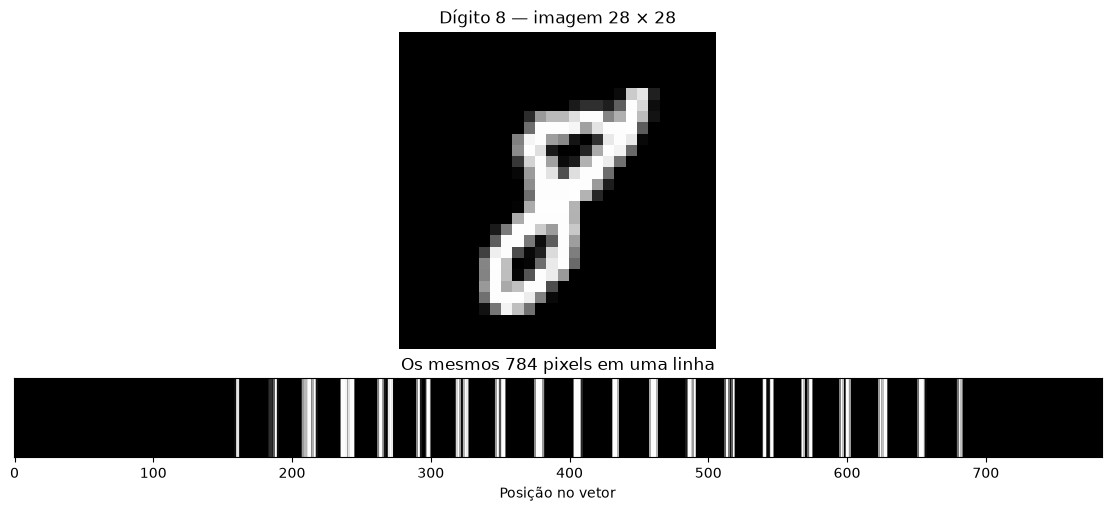

In [9]:
indice_exemplo = np.flatnonzero(y == 8)[0]
vetor = X[indice_exemplo]
imagem = vetor.reshape(28, 28)

assert np.array_equal(imagem.reshape(-1), vetor)
print("Forma do vetor:", vetor.shape)
print("Forma da imagem:", imagem.shape)
print("A transformação preservou todos os pixels:", np.array_equal(imagem.reshape(-1), vetor))

fig, axes = plt.subplots(2, 1, figsize=(11, 5), height_ratios=[4, 1], layout="constrained")
axes[0].imshow(imagem, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
axes[0].set_title(f"Dígito {y[indice_exemplo]} — imagem 28 × 28")
axes[0].axis("off")
axes[1].imshow(vetor.reshape(1, 784), cmap="gray", vmin=0, vmax=255, aspect="auto", interpolation="nearest")
axes[1].set(title="Os mesmos 784 pixels em uma linha", xlabel="Posição no vetor", yticks=[])
fig.savefig(FIGURES_DIR / "imagem_e_vetor.png", dpi=150)
plt.show()

### Síntese da análise exploratória

A base contém 70.000 imagens, com 784 intensidades inteiras entre 0 e 255 por imagem e nenhum valor ausente em `X`. As dez classes estão presentes e têm frequências próximas, mas não iguais: o dígito 1 é o mais frequente (7.877; 11,25%) e o 5 é o menos frequente (6.313; 9,02%). A transformação entre vetor e imagem preservou os pixels. Esses resultados descrevem os dados; a avaliação preditiva será realizada após a divisão em conjuntos independentes.

## 3. Divisão dos dados e normalização

Adotamos uma divisão aleatória estratificada das 70.000 imagens do OpenML: **60% treino, 10% validação, 10% calibração e 20% teste**, com semente 42. Esse protocolo é próprio do projeto e não corresponde à divisão oficial do MNIST em 60.000/10.000 imagens.

O treino ajustará os modelos; a validação selecionará configurações pelo F1 ponderado; a calibração será reservada para ajustar as probabilidades do modelo escolhido; o teste fornecerá a avaliação final. As mesmas partições serão usadas nas comparações. Nenhuma escolha de modelo deve usar os resultados do teste.

A estratificação deve preservar aproximadamente a frequência de cada dígito. Dividimos os índices das linhas para manter a correspondência entre imagens e rótulos e verificar cobertura e ausência de sobreposição.

In [10]:
indices = np.arange(len(y))
indices_restantes, indices_teste = train_test_split(
    indices, test_size=14_000, stratify=y, random_state=RANDOM_STATE,
)
indices_treino, indices_reserva = train_test_split(
    indices_restantes, test_size=14_000,
    stratify=y[indices_restantes], random_state=RANDOM_STATE,
)
indices_validacao, indices_calibracao = train_test_split(
    indices_reserva, test_size=7_000,
    stratify=y[indices_reserva], random_state=RANDOM_STATE,
)

particoes = {
    "Treino": indices_treino,
    "Validação": indices_validacao,
    "Calibração": indices_calibracao,
    "Teste": indices_teste,
}
indices_reunidos = np.concatenate(list(particoes.values()))
assert np.array_equal(np.sort(indices_reunidos), indices)
assert [len(idx) for idx in particoes.values()] == [42_000, 7_000, 7_000, 14_000]

pd.DataFrame({
    "Imagens": {nome: len(idx) for nome, idx in particoes.items()},
    "Percentual (%)": {nome: len(idx) / len(y) * 100 for nome, idx in particoes.items()},
})

,Imagens,Percentual (%)
Treino,42000,60.0
Validação,7000,10.0
Calibração,7000,10.0
Teste,14000,20.0


### Verificação da estratificação

Comparamos a proporção de cada dígito em cada conjunto com sua proporção na base integral. Pequenas diferenças são esperadas porque as quantidades de imagens precisam ser inteiras. O desvio é expresso em pontos percentuais.

In [11]:
contagens_particoes = pd.DataFrame({
    nome: np.bincount(y[idx], minlength=10)
    for nome, idx in particoes.items()
}, index=pd.Index(range(10), name="Dígito"))
proporcoes_particoes = contagens_particoes.div(contagens_particoes.sum()) * 100
proporcoes_base = np.bincount(y, minlength=10) / len(y) * 100
maior_desvio_pp = proporcoes_particoes.sub(proporcoes_base, axis=0).abs().max().max()

assert (contagens_particoes > 0).all().all()
assert np.array_equal(contagens_particoes.sum(axis=1).to_numpy(), np.bincount(y))
print(f"Maior desvio em relação à base: {maior_desvio_pp:.4f} ponto percentual")
proporcoes_particoes.round(3)

Maior desvio em relação à base: 0.0100 ponto percentual


,Treino,Validação,Calibração,Teste
Dígito,,,,
0,9.860,9.871,9.857,9.864
1,11.255,11.257,11.243,11.250
2,9.986,9.986,9.986,9.986
3,10.202,10.200,10.200,10.200
4,9.748,9.743,9.757,9.750
5,9.019,9.014,9.014,9.021
6,9.824,9.814,9.829,9.821
7,10.417,10.414,10.429,10.421
8,9.750,9.757,9.743,9.750


**Conclusão da divisão.** Foram obtidas 42.000 imagens de treino, 7.000 de validação, 7.000 de calibração e 14.000 de teste, conforme planejado. A verificação dos índices confirmou que cada linha original pertence a exatamente uma partição. As dez classes estão presentes em todos os conjuntos; o maior desvio de frequência em relação à base foi de 0,0100 ponto percentual, compatível com o arredondamento de quantidades inteiras. A divisão preservou a composição das classes. Essa checagem garante separação por linha; não é uma auditoria de imagens duplicadas na fonte.

### Normalização das intensidades

Cada pixel será convertido para `float32` e dividido por 255, passando da escala [0, 255] para [0, 1]. O divisor é fixado pela representação dos pixels e não é estimado a partir dos dados. Assim, essa transformação não aprende informações da validação, da calibração ou do teste.

Mantemos 784 atributos por imagem para KNN, Random Forest e MLP. Na etapa da CNN, a mesma informação poderá ser reorganizada em 28 × 28 × 1. Os rótulos permanecem inteiros de 0 a 9.

In [12]:
X_treino = X[indices_treino].astype(np.float32) / np.float32(255)
X_validacao = X[indices_validacao].astype(np.float32) / np.float32(255)
X_calibracao = X[indices_calibracao].astype(np.float32) / np.float32(255)
X_teste = X[indices_teste].astype(np.float32) / np.float32(255)

y_treino = y[indices_treino]
y_validacao = y[indices_validacao]
y_calibracao = y[indices_calibracao]
y_teste = y[indices_teste]

conjuntos = {
    "Treino": (X_treino, y_treino),
    "Validação": (X_validacao, y_validacao),
    "Calibração": (X_calibracao, y_calibracao),
    "Teste": (X_teste, y_teste),
}
diagnosticos = []
for nome, (pixels, rotulos) in conjuntos.items():
    assert pixels.shape == (len(rotulos), 784)
    assert pixels.dtype == np.float32
    assert np.isfinite(pixels).all()
    assert 0 <= pixels.min() <= pixels.max() <= 1
    assert np.array_equal(rotulos, y[particoes[nome]])
    diagnosticos.append({
        "Conjunto": nome, "Forma de X": str(pixels.shape),
        "Forma de y": str(rotulos.shape), "Tipo de X": str(pixels.dtype),
        "Mínimo": float(pixels.min()), "Máximo": float(pixels.max()),
    })

pd.DataFrame(diagnosticos).set_index("Conjunto")

,Forma de X,Forma de y,Tipo de X,Mínimo,Máximo
Conjunto,,,,,
Treino,"(42000, 784)","(42000,)",float32,0.0,1.0
Validação,"(7000, 784)","(7000,)",float32,0.0,1.0
Calibração,"(7000, 784)","(7000,)",float32,0.0,1.0
Teste,"(14000, 784)","(14000,)",float32,0.0,1.0


**Conclusão da normalização.** As quatro matrizes passaram a `float32`, com intensidades mínimas de 0 e máximas de 1, sem valores não finitos. Foram preservados os 784 atributos por imagem e o alinhamento entre imagens e rótulos. O resultado corresponde à escala esperada e prepara as entradas para o treinamento. A normalização não altera as classes nem demonstra ganho preditivo; o desempenho será medido nas próximas etapas.

## 4. Treinamento e seleção na validação

### 4.1. KNN — vizinhos mais próximos

Comparamos quatro configurações: 3 ou 5 vizinhos, com voto uniforme ou ponderado pelo inverso da distância. Usamos distância euclidiana (`p=2`) e busca exata (`algorithm="brute"`), adequada à representação com 784 atributos.

O critério de seleção é o F1 ponderado na validação. Em empate exato, priorizamos voto uniforme e, depois, menos vizinhos. A acurácia é apresentada como medida complementar. Os tempos de ajuste e predição são medidos separadamente, pois o KNN armazena os exemplos no ajuste e concentra seu trabalho na consulta aos vizinhos. Não usamos calibração ou teste nesta seleção.

In [13]:
resultados_knn = []
modelos_knn = {}

for n_vizinhos in (3, 5):
    for pesos in ("uniform", "distance"):
        modelo = KNeighborsClassifier(
            n_neighbors=n_vizinhos, weights=pesos,
            metric="minkowski", p=2, algorithm="brute", n_jobs=-1,
        )
        inicio = perf_counter()
        modelo.fit(X_treino, y_treino)
        tempo_ajuste = perf_counter() - inicio

        inicio = perf_counter()
        previsoes = modelo.predict(X_validacao)
        tempo_predicao = perf_counter() - inicio

        modelos_knn[(n_vizinhos, pesos)] = modelo
        resultados_knn.append({
            "n_neighbors": n_vizinhos,
            "weights": pesos,
            "F1 ponderado": f1_score(y_validacao, previsoes, average="weighted", zero_division=0),
            "Acurácia": accuracy_score(y_validacao, previsoes),
            "Tempo de ajuste (s)": tempo_ajuste,
            "Tempo de predição (s)": tempo_predicao,
        })
        print(f"Concluído: k={n_vizinhos}, weights={pesos}")

tabela_knn = pd.DataFrame(resultados_knn)
tabela_knn["ordem_pesos"] = tabela_knn["weights"].map({"uniform": 0, "distance": 1})
tabela_knn = tabela_knn.sort_values(
    ["F1 ponderado", "ordem_pesos", "n_neighbors"],
    ascending=[False, True, True],
).drop(columns="ordem_pesos").reset_index(drop=True)

melhor_configuracao_knn = tabela_knn.iloc[0]
melhor_knn = modelos_knn[(int(melhor_configuracao_knn["n_neighbors"]), melhor_configuracao_knn["weights"])]
assert np.array_equal(melhor_knn.classes_, np.arange(10))
assert len(tabela_knn) == 4
assert tabela_knn[["F1 ponderado", "Acurácia"]].ge(0).all().all()
assert tabela_knn[["F1 ponderado", "Acurácia"]].le(1).all().all()
tabela_knn.round(6)

Concluído: k=3, weights=uniform


Concluído: k=3, weights=distance


Concluído: k=5, weights=uniform


Concluído: k=5, weights=distance


,n_neighbors,weights,F1 ponderado,Acurácia,Tempo de ajuste (s),Tempo de predição (s)
0,3,distance,0.969526,0.969571,0.005249,1.307365
1,3,uniform,0.969511,0.969571,0.004819,1.362841
2,5,distance,0.968680,0.968714,0.004835,1.295544
3,5,uniform,0.967361,0.967429,0.005209,1.293550


**Conclusão do KNN.** A configuração com 3 vizinhos e pesos por distância obteve o maior F1 ponderado de validação (0,969526), com acurácia de 0,969571: 6.787 acertos entre 7.000 imagens. O voto uniforme com 3 vizinhos atingiu a mesma acurácia e F1 de 0,969511. A diferença de aproximadamente 0,000015 em F1 é muito pequena; a seleção segue o critério previamente definido, mas não demonstra superioridade estatística. A igualdade da acurácia com F1 diferente é possível porque os erros se distribuem de forma diferente entre as classes.

As configurações com 5 vizinhos tiveram F1 inferior nesta validação. Esperávamos que variar a quantidade de vizinhos e os pesos alterasse a decisão local; encontramos uma vantagem discreta de 3 vizinhos. O ajuste levou cerca de 0,005 segundo por configuração, enquanto a predição das 7.000 imagens levou aproximadamente 1,29–1,36 segundo nesta execução, coerente com a concentração do trabalho do KNN na consulta. Esses tempos dependem do equipamento e não constituem um benchmark controlado.

O estimador selecionado permanece em `melhor_knn` para comparação posterior. Os resultados são de validação; a avaliação final no teste ainda não foi realizada.